### Notebook for our Feed Forward Neural Network
This NN will predict which quartile of engagement score each post is classified to. The performance of the NN will be compared against the 768-dimensional “Ollama Nomic Text Embed” embeddings of each post in order to compare techniques for capturing text information. For each of these networks and output classes, we will report our precision, recall, F1 Score, and accuracy, along with a confusion matrix for the test data set

In [1]:
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
X_train = np.load('../data/features/X_train.npy')  
X_val   = np.load('../data/features/X_val.npy')    
X_test  = np.load('../data/features/X_test.npy')   

y_train_class  = np.load('../data/features/y_train.npy')   
y_val_class    = np.load('../data/features/y_val.npy')
y_test_class  = np.load('../data/features/y_test.npy')

idx_train    = np.load('../data/features/idx_train.npy') 
idx_val      = np.load('../data/features/idx_val.npy')
idx_test     = np.load('../data/features/idx_test.npy')

with open('../data/features/meta.pkl', 'rb') as f:
    meta = pickle.load(f)

print('X_train shape:', X_train.shape)
print('Meta keys:', list(meta.keys()))

X_train shape: (31063, 797)
Meta keys: ['feature_index', 'label_map', 'label_map_inv', 'numeric_cols', 'scaler', 'seed', 'n_train', 'n_val', 'n_test', 'total_features']


In [3]:
df_raw = pd.read_parquet('../data/moltbook_posts_flat.parquet')
print('Dataframe shape:', df_raw.shape)
print('Columns labels:', df_raw.columns.tolist())

Dataframe shape: (44376, 14)
Columns labels: ['annotation_row_id', 'topic_label', 'toxic_level', 'post_id', 'title', 'content', 'created_at', 'comment_count', 'upvotes', 'downvotes', 'url', 'submolt_id', 'submolt_name', 'submolt_display_name']


In [4]:
def compute_engagement_score(df):
    upvotes  = df['upvotes'].clip(lower=0).fillna(0)
    downvotes = df['downvotes'].clip(lower=0).fillna(0)
    comments  = df['comment_count'].clip(lower=0).fillna(0)
    return (np.log( 1+ upvotes ) + np.log( 1+ comments ) - 0.5 * np.log( 1+ downvotes ))

engagement_all = compute_engagement_score(df_raw).values

y_train_score = engagement_all[idx_train]
y_val_score  = engagement_all[idx_val]
y_test_score = engagement_all[idx_test]

### Build quartile labels
We will turn the continuous engagement score into 4 classes using quartile cutoffs computed from the full dataset. The model below is a starter FFNN baseline; `MLPClassifier` gives multiclass probabilities that sum to 1, which is the softmax-style output we want for this use case.

In [5]:
quartile_edges = np.quantile(engagement_all, [0.25, 0.5, 0.75])

label_all = np.digitize(engagement_all, bins=quartile_edges, right=True)
y_train_quartile = label_all[idx_train]
y_val_quartile = label_all[idx_val]
y_test_quartile = label_all[idx_test]

print('Quartile cutoffs:', quartile_edges)
print('Train class counts:', np.bincount(y_train_quartile, minlength=4))
print('Val class counts:', np.bincount(y_val_quartile, minlength=4))
print('Test class counts:', np.bincount(y_test_quartile, minlength=4))

Quartile cutoffs: [0.34657359 1.38629436 2.48490665]
Train class counts: [7813 8055 7481 7714]
Val class counts: [1677 1723 1603 1653]
Test class counts: [1668 1733 1603 1653]


### Train a TensorFlow/Keras FFNN
The next cell standardizes embedding features, trains a `tf.keras` feed-forward neural network with a softmax output layer, and reports accuracy, macro precision/recall/F1, and a confusion matrix on the test split.

Epoch 1/50
486/486 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.4836 - loss: 1.1081 - val_accuracy: 0.5488 - val_loss: 0.9883 - learning_rate: 0.0010
Epoch 2/50
486/486 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.5602 - loss: 0.9689 - val_accuracy: 0.5721 - val_loss: 0.9460 - learning_rate: 0.0010
Epoch 3/50
486/486 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5876 - loss: 0.9166 - val_accuracy: 0.5715 - val_loss: 0.9286 - learning_rate: 0.0010
Epoch 4/50
486/486 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6036 - loss: 0.8860 - val_accuracy: 0.5840 - val_loss: 0.9225 - learning_rate: 0.0010
Epoch 5/50
486/486 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6153 - loss: 0.8595 - val_accuracy: 0.5790 - val_loss: 0.9251 - learning_rate: 0.0010
Epoch 6/50
486/486 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6258 - loss: 0.8384 - val_accuracy: 0.5837 - val_loss: 0.9239 - learning_rate: 0.0010
Epoch 7/50
486/486 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6380 - loss: 0.8144 - 

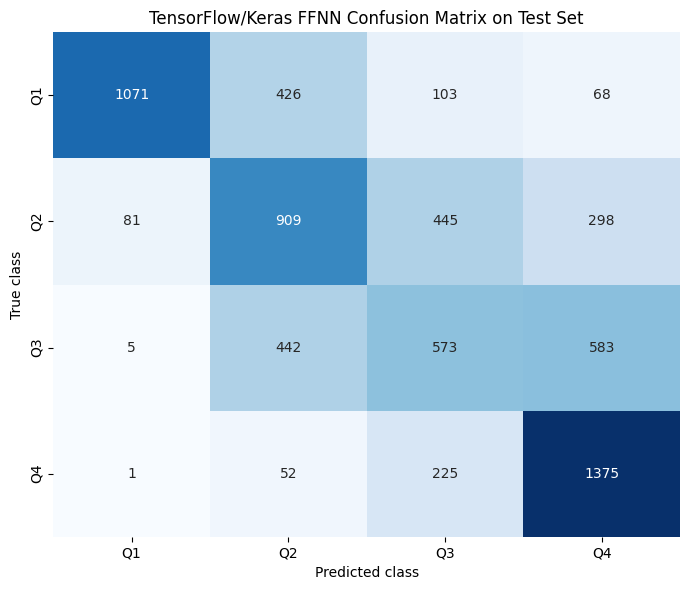

In [6]:
import tensorflow as tf
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_fscore_support
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
tf.random.set_seed(42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
X_val_scaled = scaler.transform(X_val).astype(np.float32)
X_test_scaled = scaler.transform(X_test).astype(np.float32)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(4, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        min_lr=1e-6,
        verbose=1,
    ),
]

history = model.fit(
    X_train_scaled,
    y_train_quartile,
    validation_data=(X_val_scaled, y_val_quartile),
    epochs=50,
    batch_size=64,
    callbacks=callbacks,
    verbose=1,
)

test_prob = model.predict(X_test_scaled, verbose=0)
test_pred = np.argmax(test_prob, axis=1)

test_accuracy = accuracy_score(y_test_quartile, test_pred)
macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
    y_test_quartile,
    test_pred,
    average='macro',
    zero_division=0,
)

print(f'Test accuracy: {test_accuracy:.4f}')
print(f'Macro precision: {macro_precision:.4f}')
print(f'Macro recall: {macro_recall:.4f}')
print(f'Macro F1: {macro_f1:.4f}')
print('\nClassification report:\n')
print(classification_report(y_test_quartile, test_pred, digits=4, zero_division=0))

cm = confusion_matrix(y_test_quartile, test_pred, labels=[0, 1, 2, 3])
plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=['Q1', 'Q2', 'Q3', 'Q4'],
    yticklabels=['Q1', 'Q2', 'Q3', 'Q4'],
)
plt.xlabel('Predicted class')
plt.ylabel('True class')
plt.title('TensorFlow/Keras FFNN Confusion Matrix on Test Set')
plt.tight_layout()
plt.show()

### Compare hidden-layer and activation combinations
Instead of creating many nearly identical training cells, we can run a small grid of architecture and activation choices in a loop, collect metrics, and sort results to pick the best model.

In [7]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.preprocessing import StandardScaler

# Keep preprocessing in this section so it can be run independently.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
X_val_scaled = scaler.transform(X_val).astype(np.float32)
X_test_scaled = scaler.transform(X_test).astype(np.float32)

experiment_configs = [
    {"name": "relu_256_128", "hidden_layers": (256, 128), "activation": "relu", "dropout": 0.25},
    {"name": "relu_512_256", "hidden_layers": (512, 256), "activation": "relu", "dropout": 0.30},
    {"name": "tanh_256_128", "hidden_layers": (256, 128), "activation": "tanh", "dropout": 0.25},
    {"name": "tanh_512_256", "hidden_layers": (512, 256), "activation": "tanh", "dropout": 0.30},
    {"name": "elu_256_128", "hidden_layers": (256, 128), "activation": "elu", "dropout": 0.25},
    {"name": "elu_512_256", "hidden_layers": (512, 256), "activation": "elu", "dropout": 0.30},
]

def build_ffnn(input_dim, hidden_layers, activation, dropout):
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=(input_dim,)))

    for units in hidden_layers:
        model.add(tf.keras.layers.Dense(units, activation=activation))
        model.add(tf.keras.layers.Dropout(dropout))

    model.add(tf.keras.layers.Dense(4, activation='softmax'))
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model

In [8]:
results = []

for cfg in experiment_configs:
    tf.keras.backend.clear_session()
    np.random.seed(42)
    tf.random.set_seed(42)

    model = build_ffnn(
        input_dim=X_train_scaled.shape[1],
        hidden_layers=cfg['hidden_layers'],
        activation=cfg['activation'],
        dropout=cfg['dropout'],
    )

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=6,
            restore_best_weights=True,
            verbose=0,
        )
    ]

    history = model.fit(
        X_train_scaled,
        y_train_quartile,
        validation_data=(X_val_scaled, y_val_quartile),
        epochs=30,
        batch_size=64,
        callbacks=callbacks,
        verbose=0,
    )

    val_prob = model.predict(X_val_scaled, verbose=0)
    val_pred = np.argmax(val_prob, axis=1)

    test_prob = model.predict(X_test_scaled, verbose=0)
    test_pred = np.argmax(test_prob, axis=1)

    val_acc = accuracy_score(y_val_quartile, val_pred)
    test_acc = accuracy_score(y_test_quartile, test_pred)
    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        y_test_quartile,
        test_pred,
        average='macro',
        zero_division=0,
    )

    results.append({
        'name': cfg['name'],
        'hidden_layers': str(cfg['hidden_layers']),
        'activation': cfg['activation'],
        'dropout': cfg['dropout'],
        'best_epoch': int(np.argmin(history.history['val_loss']) + 1),
        'val_accuracy': val_acc,
        'test_accuracy': test_acc,
        'test_macro_precision': macro_precision,
        'test_macro_recall': macro_recall,
        'test_macro_f1': macro_f1,
    })

results_df = pd.DataFrame(results).sort_values(
    by=['test_macro_f1', 'test_accuracy'],
    ascending=False,
).reset_index(drop=True)

print('Model comparison sorted by macro F1 then accuracy:')
display(results_df)

best_config = results_df.iloc[0]
print('\nBest configuration:')
print(best_config[['name', 'hidden_layers', 'activation', 'dropout', 'test_accuracy', 'test_macro_f1']])


Model comparison sorted by macro F1 then accuracy:


,name,hidden_layers,activation,dropout,best_epoch,val_accuracy,test_accuracy,test_macro_precision,test_macro_recall,test_macro_f1
0,elu_512_256,"(512, 256)",elu,0.30,3,0.577374,0.588704,0.610644,0.586848,0.587005
1,elu_256_128,"(256, 128)",elu,0.25,4,0.578576,0.587201,0.603161,0.586623,0.586737
2,relu_512_256,"(512, 256)",relu,0.30,5,0.580679,0.582094,0.601220,0.580440,0.580270
3,tanh_512_256,"(512, 256)",tanh,0.30,4,0.574219,0.581643,0.588515,0.580739,0.579504
4,relu_256_128,"(256, 128)",relu,0.25,3,0.577224,0.580892,0.599123,0.580079,0.579413
5,tanh_256_128,"(256, 128)",tanh,0.25,4,0.577374,0.580442,0.589683,0.578931,0.577351



Best configuration:
name             elu_512_256
hidden_layers     (512, 256)
activation               elu
dropout                  0.3
test_accuracy       0.588704
test_macro_f1       0.587005
Name: 0, dtype: object


Retraining best config:
{'hidden_layers': (512, 256), 'activation': 'elu', 'dropout': 0.3}
Epoch 1/80
486/486 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.4945 - loss: 1.2036 - val_accuracy: 0.5631 - val_loss: 0.9727 - learning_rate: 0.0010
Epoch 2/80
486/486 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5689 - loss: 0.9535 - val_accuracy: 0.5744 - val_loss: 0.9358 - learning_rate: 0.0010
Epoch 3/80
486/486 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5987 - loss: 0.8999 - val_accuracy: 0.5756 - val_loss: 0.9343 - learning_rate: 0.0010
Epoch 4/80
486/486 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6116 - loss: 0.8790 - val_accuracy: 0.5786 - val_loss: 0.9331 - learning_rate: 0.0010
Epoch 5/80
486/486 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6215 - loss: 0.8586 - val_accuracy: 0.5757 - val_loss: 0.9360 - learning_rate: 0.0010
Epoch 6/80
486/486 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.6316 - loss: 0.8381 - val_accuracy: 0.5781 - val_loss: 0.9444 - learning_rate: 0.00

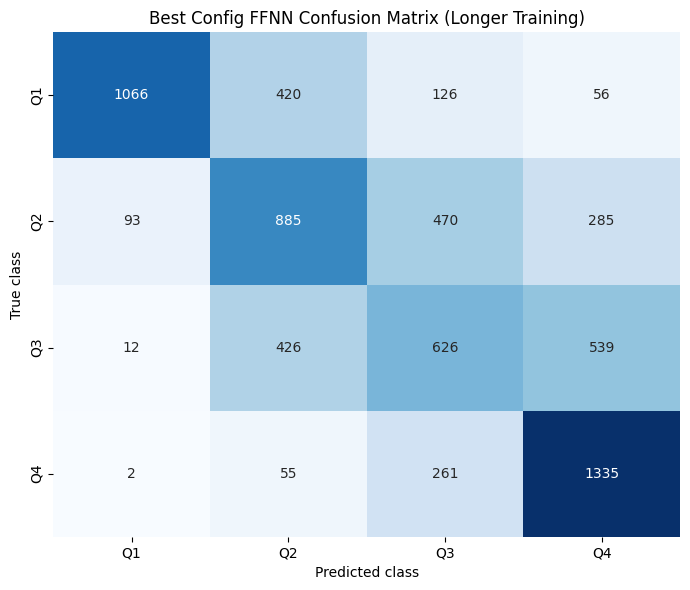

In [9]:
# Retrain the best architecture for longer and plot its confusion matrix.
if 'best_config' not in globals():
    raise ValueError('Run the model-comparison cell first so best_config is available.')

best_hidden_layers = tuple(int(x.strip()) for x in best_config['hidden_layers'].strip('()').split(','))
best_activation = best_config['activation']
best_dropout = float(best_config['dropout'])

print('Retraining best config:')
print({'hidden_layers': best_hidden_layers, 'activation': best_activation, 'dropout': best_dropout})

tf.keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

best_model = build_ffnn(
    input_dim=X_train_scaled.shape[1],
    hidden_layers=best_hidden_layers,
    activation=best_activation,
    dropout=best_dropout,
)

long_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1,
    ),
]

long_history = best_model.fit(
    X_train_scaled,
    y_train_quartile,
    validation_data=(X_val_scaled, y_val_quartile),
    epochs=80,
    batch_size=64,
    callbacks=long_callbacks,
    verbose=1,
)

best_test_prob = best_model.predict(X_test_scaled, verbose=0)
best_test_pred = np.argmax(best_test_prob, axis=1)

best_test_acc = accuracy_score(y_test_quartile, best_test_pred)
best_macro_precision, best_macro_recall, best_macro_f1, _ = precision_recall_fscore_support(
    y_test_quartile,
    best_test_pred,
    average='macro',
    zero_division=0,
)

print(f'Test accuracy: {best_test_acc:.4f}')
print(f'Macro precision: {best_macro_precision:.4f}')
print(f'Macro recall: {best_macro_recall:.4f}')
print(f'Macro F1: {best_macro_f1:.4f}')

best_cm = confusion_matrix(y_test_quartile, best_test_pred, labels=[0, 1, 2, 3])
plt.figure(figsize=(7, 6))
sns.heatmap(
    best_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=['Q1', 'Q2', 'Q3', 'Q4'],
    yticklabels=['Q1', 'Q2', 'Q3', 'Q4'],
)
plt.xlabel('Predicted class')
plt.ylabel('True class')
plt.title('Best Config FFNN Confusion Matrix (Longer Training)')
plt.tight_layout()
plt.show()